# MammoAI — Breast Cancer Image Classification
**Dataset:** Breast Cancer Detection — Mammography Images (Kaggle: hayder17/breast-cancer-detection)  
**Model:** EfficientNetB0 Transfer Learning (TensorFlow / Keras)  
**Goal:** Binary image classification — Malignant vs Benign mammograms

Dataset structure:
```
data/
  train/  0/ (benign)    1/ (malignant)
  valid/  0/ (benign)    1/ (malignant)
  test/   0/ (benign)    1/ (malignant)
```

## 0. Setup

In [17]:
import json
import warnings
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'GPUs       : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.21.0
NumPy      : 2.5.0
GPUs       : []


In [18]:
DATA_ROOT  = Path('../data')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

IMG_SIZE   = 224
BATCH_SIZE = 32

# Folders '0' and '1' sorted alphabetically → label 0 = benign, label 1 = malignant
CLASS_NAMES = ['benign', 'malignant']
NUM_CLASSES = 2

# Sanity check
for split in ['train', 'valid', 'test']:
    counts = {}
    for folder, name in [('0', 'benign'), ('1', 'malignant')]:
        d = DATA_ROOT / split / folder
        n = len(list(d.glob('*.jpg')) + list(d.glob('*.png'))) if d.exists() else 0
        counts[name] = n
    print(f'{split:6s}: {counts}')

assert (DATA_ROOT / 'train' / '0').exists(), \
    f'Training data not found. Expected data/train/0/ and data/train/1/'

train : {'benign': 1569, 'malignant': 803}
valid : {'benign': 448, 'malignant': 227}
test  : {'benign': 208, 'malignant': 128}


## 1. EDA — Distribution and Sample Images

In [19]:
# Build and save class distribution for Streamlit app
dist = {'class_names': CLASS_NAMES}
all_counts = {'benign': 0, 'malignant': 0}
for split in ['train', 'valid', 'test']:
    split_counts = {}
    for folder, name in [('0', 'benign'), ('1', 'malignant')]:
        d = DATA_ROOT / split / folder
        n = len(list(d.glob('*.jpg')) + list(d.glob('*.png'))) if d.exists() else 0
        split_counts[name] = n
        all_counts[name] += n
    dist[split] = split_counts
dist['all'] = all_counts

with open(MODELS_DIR / 'class_distribution.json', 'w') as f:
    json.dump(dist, f, indent=2)
print('Class distribution:', dist)

Class distribution: {'class_names': ['benign', 'malignant'], 'train': {'benign': 1569, 'malignant': 803}, 'valid': {'benign': 448, 'malignant': 227}, 'test': {'benign': 208, 'malignant': 128}, 'all': {'benign': 2225, 'malignant': 1158}}


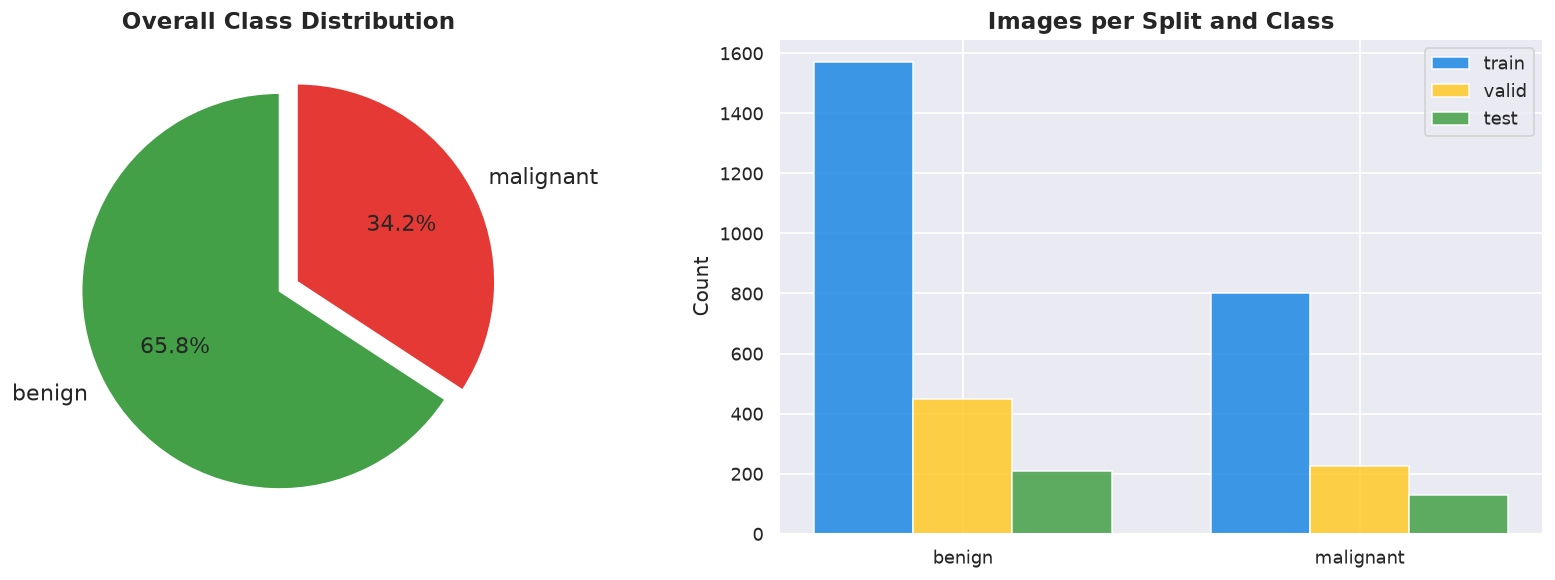

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#43A047', '#E53935']

axes[0].pie(
    list(all_counts.values()), labels=list(all_counts.keys()),
    colors=colors, autopct='%1.1f%%', startangle=90,
    explode=(0.05, 0.05), textprops={'fontsize': 13}
)
axes[0].set_title('Overall Class Distribution', fontsize=14, fontweight='bold')

x = np.arange(2)
width = 0.25
for i, (split, color) in enumerate([('train', '#1E88E5'), ('valid', '#FFCA28'), ('test', '#43A047')]):
    vals = [dist[split].get(n, 0) for n in CLASS_NAMES]
    axes[1].bar(x + i * width, vals, width, label=split, color=color, alpha=0.85)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(CLASS_NAMES)
axes[1].set_title('Images per Split and Class', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(MODELS_DIR / 'eda_distribution.png', bbox_inches='tight')
plt.show()

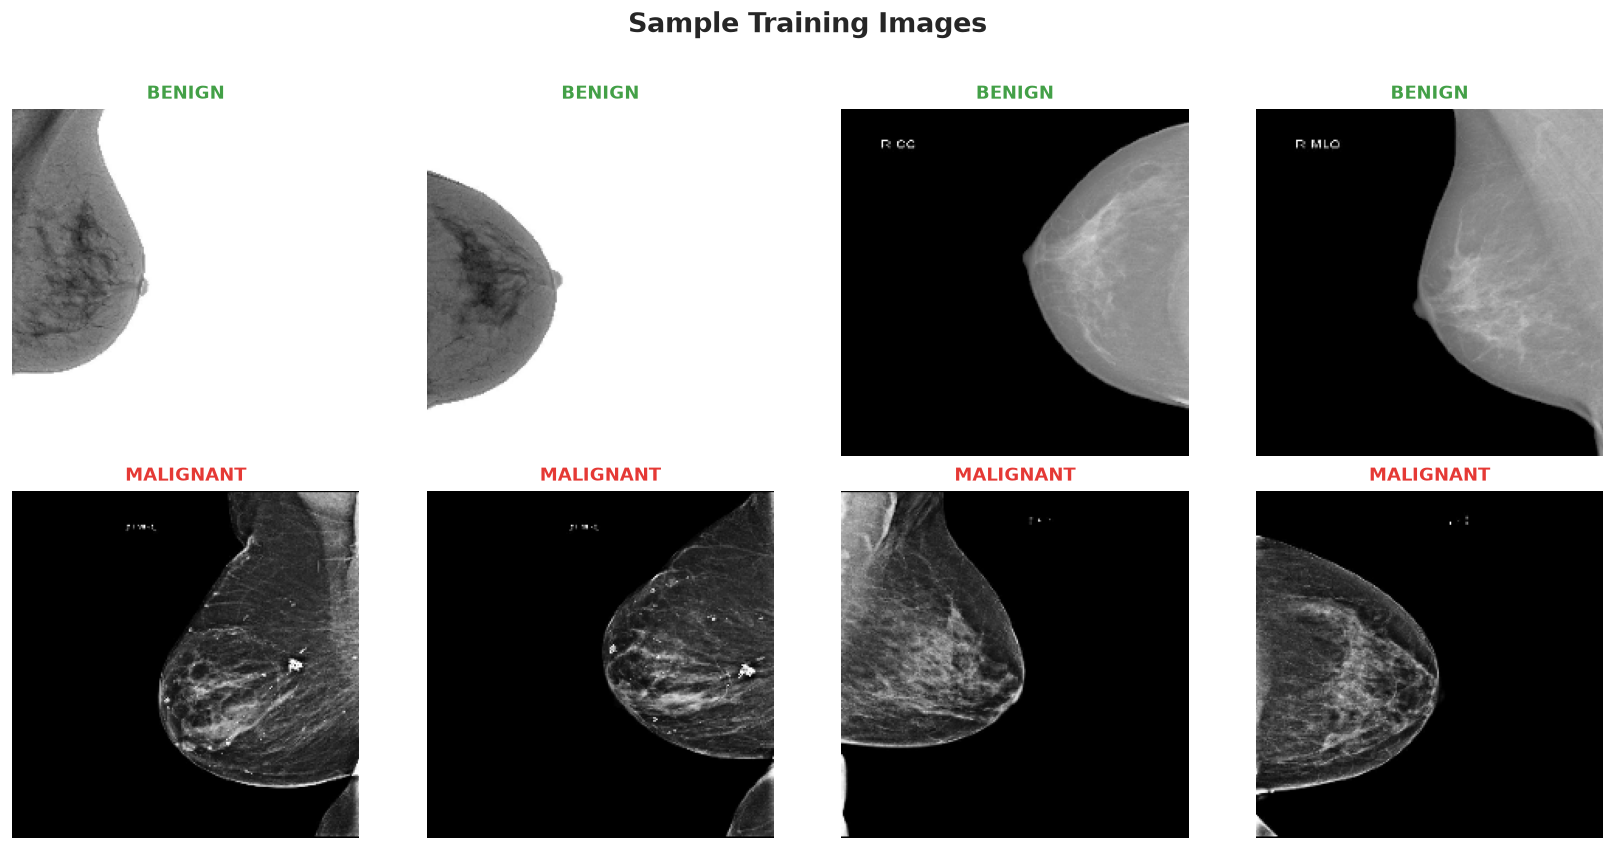

In [21]:
# Sample images grid
samples_per_class = 4
fig, axes = plt.subplots(2, samples_per_class, figsize=(samples_per_class * 3.5, 7))

for row, (folder, cls_name) in enumerate([('0', 'benign'), ('1', 'malignant')]):
    img_dir   = DATA_ROOT / 'train' / folder
    img_files = sorted(img_dir.glob('*.jpg'))[:samples_per_class]
    color     = '#43A047' if cls_name == 'benign' else '#E53935'
    for col, img_path in enumerate(img_files):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls_name.upper(), fontsize=11, fontweight='bold', color=color)
        axes[row, col].axis('off')

plt.suptitle('Sample Training Images', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'eda_samples.png', bbox_inches='tight')
plt.show()

In [22]:
# Image size stats
widths, heights = [], []
for folder in ['0', '1']:
    for p in sorted((DATA_ROOT / 'train' / folder).glob('*.jpg'))[:50]:
        img = cv2.imread(str(p))
        if img is not None:
            h, w = img.shape[:2]
            widths.append(w)
            heights.append(h)

if widths:
    print(f'Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
    print(f'Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')

Width  — min: 640, max: 640, mean: 640
Height — min: 640, max: 640, mean: 640


## 2. tf.data Pipeline

In [23]:
def make_dataset(split: str, shuffle: bool = False, augment: bool = False) -> tf.data.Dataset:
    """
    Load images from data/<split>/0/ (benign) and data/<split>/1/ (malignant).
    image_dataset_from_directory with class_names=['0','1'] ensures:
      folder '0' → label 0 (benign)
      folder '1' → label 1 (malignant)
    Images are returned as float32 in [0, 255].
    preprocess_input (→ [-1,1]) is applied inside the model.
    """
    ds = tf.keras.utils.image_dataset_from_directory(
        DATA_ROOT / split,
        labels='inferred',
        label_mode='binary',
        class_names=['0', '1'],   # explicit: '0'=benign(0), '1'=malignant(1)
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=42,
        color_mode='rgb',
    )

    def augment_fn(img, lbl):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, max_delta=30.0)
        img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
        img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
        img = tf.clip_by_value(img, 0.0, 255.0)
        return img, lbl

    AUTOTUNE = tf.data.AUTOTUNE
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_dataset('train', shuffle=True,  augment=True)
valid_ds = make_dataset('valid', shuffle=False, augment=False)
test_ds  = make_dataset('test',  shuffle=False, augment=False)

print('Datasets ready.')
for imgs, lbls in train_ds.take(1):
    print(f'images: {imgs.shape}  dtype: {imgs.dtype}  '
          f'pixel range: [{imgs.numpy().min():.0f}, {imgs.numpy().max():.0f}]')
    print(f'labels: {lbls.shape}  unique: {np.unique(lbls.numpy())}')

Found 2372 files belonging to 2 classes.
Found 675 files belonging to 2 classes.
Found 336 files belonging to 2 classes.
Datasets ready.
images: (32, 224, 224, 3)  dtype: <dtype: 'float32'>  pixel range: [26, 255]
labels: (32, 1)  unique: [0. 1.]


Found 2372 files belonging to 2 classes.


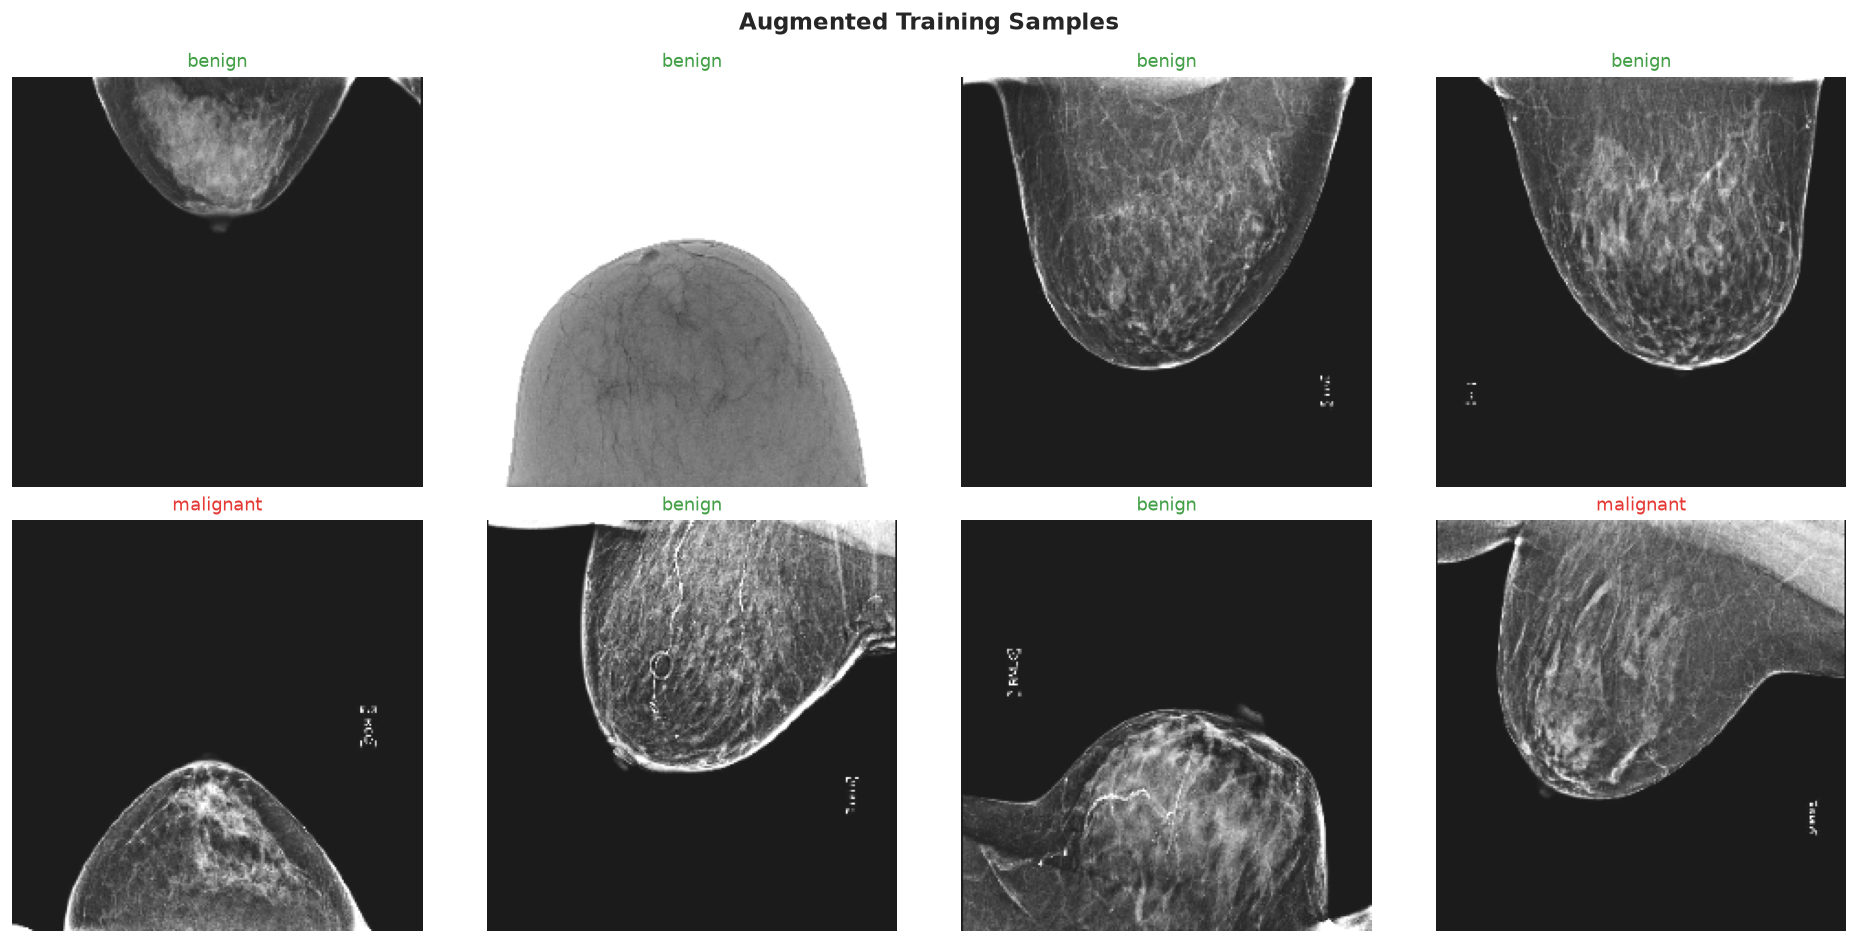

In [24]:
# Visualise augmented samples
aug_batch_imgs, aug_batch_lbls = next(iter(make_dataset('train', shuffle=True, augment=True)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, img, lbl in zip(axes.flatten(), aug_batch_imgs[:8], aug_batch_lbls[:8]):
    ax.imshow(img.numpy().astype(np.uint8))
    # label_mode='binary' gives shape (1,) per sample — use .item() to get scalar
    cls_name = CLASS_NAMES[int(lbl.numpy().item())]
    ax.set_title(cls_name, fontsize=11,
                 color='#E53935' if cls_name == 'malignant' else '#43A047')
    ax.axis('off')

plt.suptitle('Augmented Training Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Model — EfficientNetB0 Transfer Learning

In [ ]:
def build_model():
    """Returns (model, base_model). base_model kept in scope for Phase 2."""
    base = EfficientNetB0(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False  # Phase 1: frozen

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image_input')
    # preprocess_input: [0,255] → [-1,1] (EfficientNet expects this range)
    # Named function + explicit output_shape (not a wrapping lambda, no shape inference
    # needed) so Keras 3 can safely reconstruct this layer on load.
    x = layers.Lambda(preprocess_input, output_shape=lambda s: s, name='preprocess')(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(256, activation='relu', name='dense_256')(x)
    x = layers.BatchNormalization(name='bn')(x)
    x = layers.Dropout(0.5, name='drop_256')(x)
    x = layers.Dense(128, activation='relu', name='dense_128')(x)
    x = layers.Dropout(0.3, name='drop_128')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = keras.Model(inputs, outputs, name='MammoAI')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )
    return model, base

model, base_model = build_model()
model.summary()

## 4. Training — Phase 1: Head Only

In [26]:
checkpoint_cb = ModelCheckpoint(
    str(MODELS_DIR / 'best_model.keras'),
    save_best_only=True, monitor='val_auc', mode='max', verbose=1
)
early_stop_cb = EarlyStopping(
    monitor='val_auc', mode='max', patience=10,
    restore_best_weights=True, verbose=1
)
reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1
)

print('Phase 1: training head (base frozen)...')
history1 = model.fit(
    train_ds, validation_data=valid_ds,
    epochs=20,
    callbacks=[checkpoint_cb, early_stop_cb, reduce_lr_cb],
    verbose=1
)
print('Phase 1 done.')

Phase 1: training head (base frozen)...
Epoch 1/20


W0000 00:00:1782891436.489200  105599 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1782891436.559964  105599 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1782891436.590320  105599 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1782891436.618127  105599 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1782891436.645500  105599 cpu_allocator_impl.cc:82] Allocation of 154140672 exceeds 10% of free system memory.


75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.6020 - auc: 0.5576 - loss: 0.8050 - precision: 0.3965 - recall: 0.3362
Epoch 1: val_auc improved from None to 0.60939, saving model to ../models/best_model.keras

Epoch 1: finished saving model to ../models/best_model.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 51s 572ms/step - accuracy: 0.6020 - auc: 0.5576 - loss: 0.8050 - precision: 0.3965 - recall: 0.3362 - val_accuracy: 0.6252 - val_auc: 0.6094 - val_loss: 0.6505 - val_precision: 0.4398 - val_recall: 0.4185 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.6117 - auc: 0.5722 - loss: 0.7279 - precision: 0.4026 - recall: 0.3039
Epoch 2: val_auc did not improve from 0.60939
75/75 ━━━━━━━━━━━━━━━━━━━━ 39s 512ms/step - accuracy: 0.6117 - auc: 0.5722 - loss: 0.7279 - precision: 0.4026 - recall: 0.3039 - val_accuracy: 0.6237 - val_auc: 0.6088 - val_loss: 0.6639 - val_precision: 0.4270 - val_recall: 0.3480 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━

KeyboardInterrupt: 

## 4b. Training — Phase 2: Fine-Tune Top Layers

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f'Trainable params: {sum(np.prod(v.shape) for v in model.trainable_weights):,}')

# Recompile with fresh metric objects (never reuse model.metrics after training)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

print('Phase 2: fine-tuning top 30 EfficientNet layers...')
history2 = model.fit(
    train_ds, validation_data=valid_ds,
    epochs=50,
    callbacks=[
        checkpoint_cb,
        EarlyStopping(monitor='val_auc', mode='max', patience=15,
                      restore_best_weights=True, verbose=1),
        reduce_lr_cb,
    ],
    verbose=1
)
print('Phase 2 done.')

In [ ]:
# Merge histories and save
history_all = {k: history1.history[k] + history2.history.get(k, []) for k in history1.history}
with open(MODELS_DIR / 'training_history.json', 'w') as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history_all.items()}, f, indent=2)
print('History saved.')

phase1_end = len(history1.history['loss'])
epoch_nums = range(1, len(history_all['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, metric, val_metric, title in [
    (axes[0], 'loss',     'val_loss',     'Loss'),
    (axes[1], 'accuracy', 'val_accuracy', 'Accuracy'),
]:
    ax.plot(epoch_nums, history_all[metric],     color='#1E88E5', linewidth=2, label='Train')
    ax.plot(epoch_nums, history_all[val_metric], color='#E53935', linewidth=2,
            linestyle='--', label='Validation')
    ax.axvline(phase1_end, color='#FFCA28', linestyle=':', linewidth=1.5, label='Fine-tune start')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'training_curves.png', bbox_inches='tight')
plt.show()

## 5. Evaluation

In [ ]:
best_model = keras.models.load_model(str(MODELS_DIR / 'best_model.keras'), safe_mode=False)
print('Best checkpoint loaded.')

y_prob = best_model.predict(test_ds, verbose=1).flatten()
y_pred = (y_prob >= 0.5).astype(int)
# Collect true labels from dataset in order (shuffle=False)
y_true = np.concatenate([lbls.numpy().flatten() for _, lbls in test_ds]).astype(int)

print(f'Test samples: {len(y_true)}')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [ ]:
acc  = accuracy_score(y_true, y_pred)
auc  = roc_auc_score(y_true, y_prob)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)
cm   = confusion_matrix(y_true, y_pred)
fpr, tpr, _        = roc_curve(y_true, y_prob)
pr_prec, pr_rec, _ = precision_recall_curve(y_true, y_prob)

print(f'Accuracy : {acc:.4f}  |  AUC: {auc:.4f}  |  F1: {f1:.4f}')
print(f'Precision: {prec:.4f}  |  Recall: {rec:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
annot  = np.array([[f'{v}\n({p:.1%})' for v, p in zip(rv, rp)] for rv, rp in zip(cm, cm_pct)])
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar=False, annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

axes[1].plot(fpr, tpr, color='#1E88E5', linewidth=2.5, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#1E88E5')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(pr_rec, pr_prec, color='#E53935', linewidth=2.5)
axes[2].fill_between(pr_rec, pr_prec, alpha=0.1, color='#E53935')
axes[2].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'evaluation_charts.png', bbox_inches='tight')
plt.show()

with open(MODELS_DIR / 'model_metrics.json', 'w') as f:
    json.dump({
        'accuracy': float(acc), 'auc': float(auc),
        'precision': float(prec), 'recall': float(rec), 'f1': float(f1),
        'confusion_matrix': cm.tolist(),
        'roc_fpr': fpr.tolist(), 'roc_tpr': tpr.tolist(),
        'pr_precision': pr_prec.tolist(), 'pr_recall': pr_rec.tolist(),
        'class_names': CLASS_NAMES,
        'test_size': int(len(y_true)),
        'train_size': int(dist['train']['benign'] + dist['train']['malignant']),
    }, f, indent=2)
print('Metrics saved.')

In [ ]:
# Prediction grid — batch inference
grid_imgs, grid_trues, grid_preds, grid_probs = [], [], [], []
for imgs_b, lbls_b in test_ds:
    probs_b = best_model.predict(imgs_b, verbose=0).flatten()
    for img, lbl, prob in zip(imgs_b.numpy(), lbls_b.numpy().flatten(), probs_b):
        grid_imgs.append(img)
        grid_trues.append(CLASS_NAMES[int(lbl)])
        grid_preds.append(CLASS_NAMES[int(prob >= 0.5)])
        grid_probs.append(float(prob))
    if len(grid_imgs) >= 16:
        break

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for ax, img, true_cls, pred_cls, prob in zip(
    axes.flatten(), grid_imgs, grid_trues, grid_preds, grid_probs
):
    ax.imshow(img.astype(np.uint8))
    conf = prob if pred_cls == 'malignant' else 1 - prob
    ax.set_title(f'P: {pred_cls} ({conf:.0%})\nT: {true_cls}',
                 fontsize=8, color='green' if pred_cls == true_cls else 'red')
    ax.axis('off')

plt.suptitle('Test Predictions  (green = correct, red = wrong)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'prediction_grid.png', bbox_inches='tight')
plt.show()

## 6. Save Final Model

In [ ]:
best_model.save(str(MODELS_DIR / 'model.keras'))

with open(MODELS_DIR / 'app_config.json', 'w') as f:
    json.dump({'img_size': IMG_SIZE, 'num_classes': NUM_CLASSES, 'class_names': CLASS_NAMES}, f, indent=2)

print('\n=== Artifacts saved to models/ ===')
for p in sorted(MODELS_DIR.iterdir()):
    print(f'  {p.name:<35} {p.stat().st_size/1024:>9.1f} KB')